# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "pneumoniamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

In [ ]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.33MB/s]


(4708, 524, 624)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


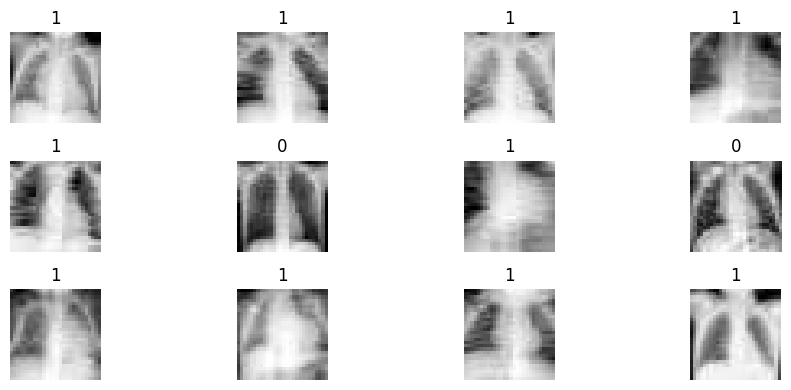

In [ ]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 8
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5941 | val_acc=0.7424 | val_auc=0.5842
Epoch 02 | train_loss=0.5446 | val_acc=0.7424 | val_auc=0.8271
Epoch 03 | train_loss=0.4418 | val_acc=0.8302 | val_auc=0.9135
Epoch 04 | train_loss=0.3525 | val_acc=0.8359 | val_auc=0.9129
Epoch 05 | train_loss=0.3314 | val_acc=0.8454 | val_auc=0.9180
Epoch 06 | train_loss=0.2993 | val_acc=0.8569 | val_auc=0.9304
Epoch 07 | train_loss=0.2791 | val_acc=0.8721 | val_auc=0.9402
Epoch 08 | train_loss=0.2651 | val_acc=0.8721 | val_auc=0.9535


### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


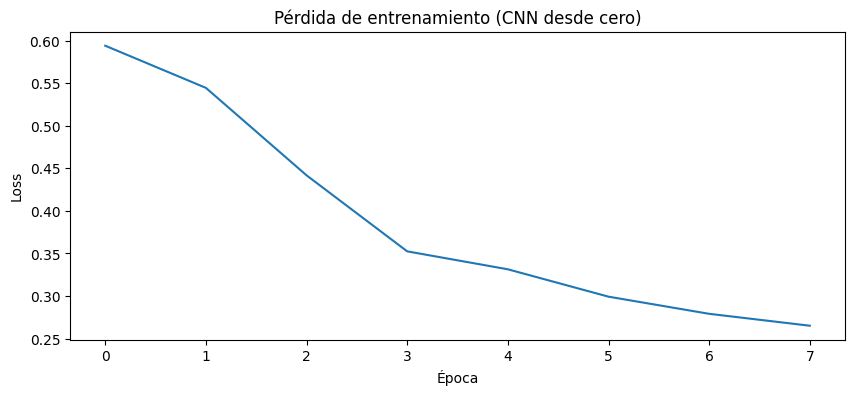

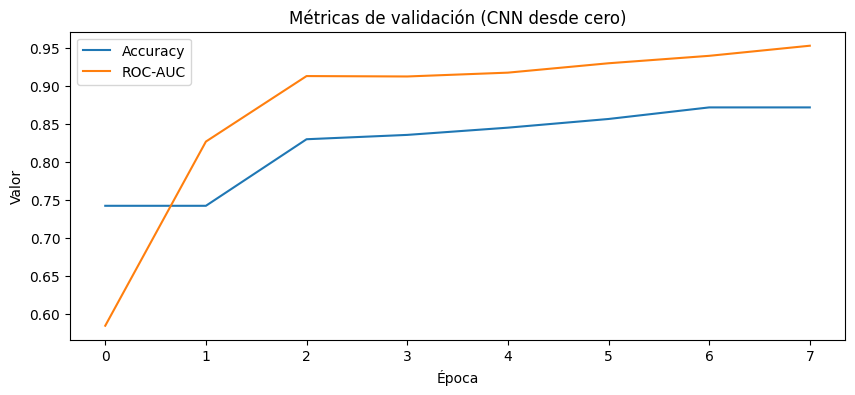

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [ ]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8702
Test ROC-AUC:  0.9428

              precision    recall  f1-score   support

           0     0.8024    0.8675    0.8337       234
           1     0.9164    0.8718    0.8936       390

    accuracy                         0.8702       624
   macro avg     0.8594    0.8697    0.8636       624
weighted avg     0.8737    0.8702    0.8711       624



array([[203,  31],
       [ 50, 340]])

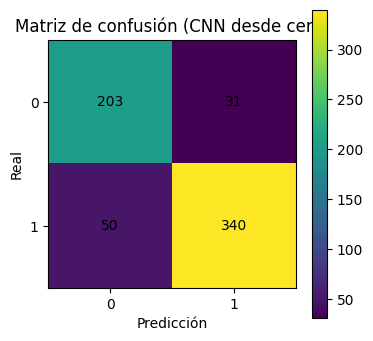

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [ ]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [ ]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5887 | val_acc=0.7424 | val_auc=0.5197
Epoch 02 | train_loss=0.5703 | val_acc=0.7424 | val_auc=0.5926
Epoch 03 | train_loss=0.5695 | val_acc=0.7424 | val_auc=0.7218
Epoch 04 | train_loss=0.5635 | val_acc=0.7424 | val_auc=0.7552
Epoch 05 | train_loss=0.5453 | val_acc=0.7424 | val_auc=0.9044
Epoch 06 | train_loss=0.4763 | val_acc=0.7481 | val_auc=0.9125


### 6.1. Comparación rápida


In [ ]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8702 | test_auc=0.9428
Con augmentation  | test_acc=0.6266 | test_auc=0.9143


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [ ]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 227MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.4019 | val_acc=0.8034 | val_auc=0.8836
Stage1 Epoch 02 | train_loss=0.3090 | val_acc=0.8664 | val_auc=0.9398
Stage1 Epoch 03 | train_loss=0.2724 | val_acc=0.8683 | val_auc=0.9443
Stage1 Epoch 04 | train_loss=0.2536 | val_acc=0.8817 | val_auc=0.9472


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [ ]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [ ]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.1517 | val_acc=0.9351 | val_auc=0.9878
Stage2 Epoch 02 | train_loss=0.1057 | val_acc=0.9103 | val_auc=0.9879
Stage2 Epoch 03 | train_loss=0.0778 | val_acc=0.9676 | val_auc=0.9930
Stage2 Epoch 04 | train_loss=0.0649 | val_acc=0.9294 | val_auc=0.9933


### 7.3. Evaluación en test del modelo con transfer learning


In [ ]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.9263 | test_auc=0.9806

              precision    recall  f1-score   support

           0     0.9563    0.8419    0.8955       234
           1     0.9115    0.9769    0.9431       390

    accuracy                         0.9263       624
   macro avg     0.9339    0.9094    0.9193       624
weighted avg     0.9283    0.9263    0.9252       624



array([[197,  37],
       [  9, 381]])

### 7.4. Comparación global (resumen)


In [ ]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8702 | auc=0.9428
CNN desde cero (con aug)  | acc=0.6266 | auc=0.9143
Transfer learning (ResNet) | acc=0.9263 | auc=0.9806


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [ ]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


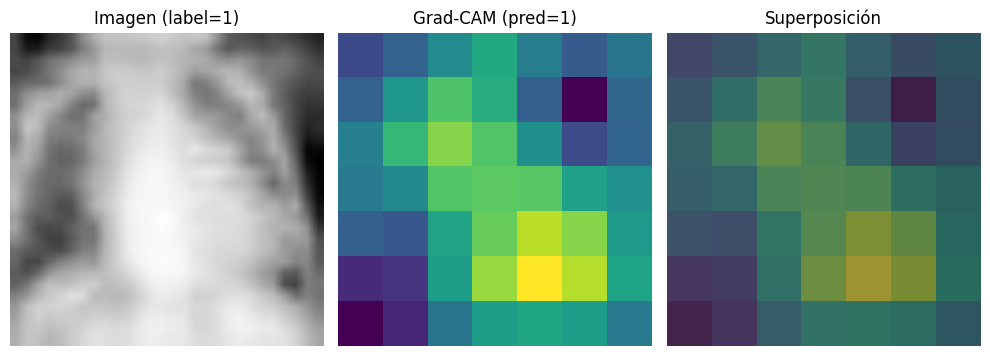

In [ ]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [ ]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.


Device     : cuda
Num clases : 14
Clases     : ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration', 'mass', 'nodule', 'pneumonia', 'pneumothorax', 'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']
Tarea      : multi-label, binary-class
Muestras   : {'train': 78468, 'val': 11219, 'test': 22433}

── 1. Cargando ChestMNIST ──


100%|██████████| 82.8M/82.8M [00:07<00:00, 10.9MB/s]



Forma imagen  : torch.Size([128, 1, 28, 28])
Forma etiqueta: torch.Size([128, 14])
Tipo etiqueta : torch.int64

Distribución de clases en train:
  atelectasis              :  7996 (10.2%)
  cardiomegaly             :  1950 (2.5%)
  effusion                 :  9261 (11.8%)
  infiltration             : 13914 (17.7%)
  mass                     :  3988 (5.1%)
  nodule                   :  4375 (5.6%)
  pneumonia                :   978 (1.2%)
  pneumothorax             :  3705 (4.7%)
  consolidation            :  3263 (4.2%)
  edema                    :  1690 (2.2%)
  emphysema                :  1799 (2.3%)
  fibrosis                 :  1158 (1.5%)
  pleural                  :  2279 (2.9%)
  hernia                   :   144 (0.2%)


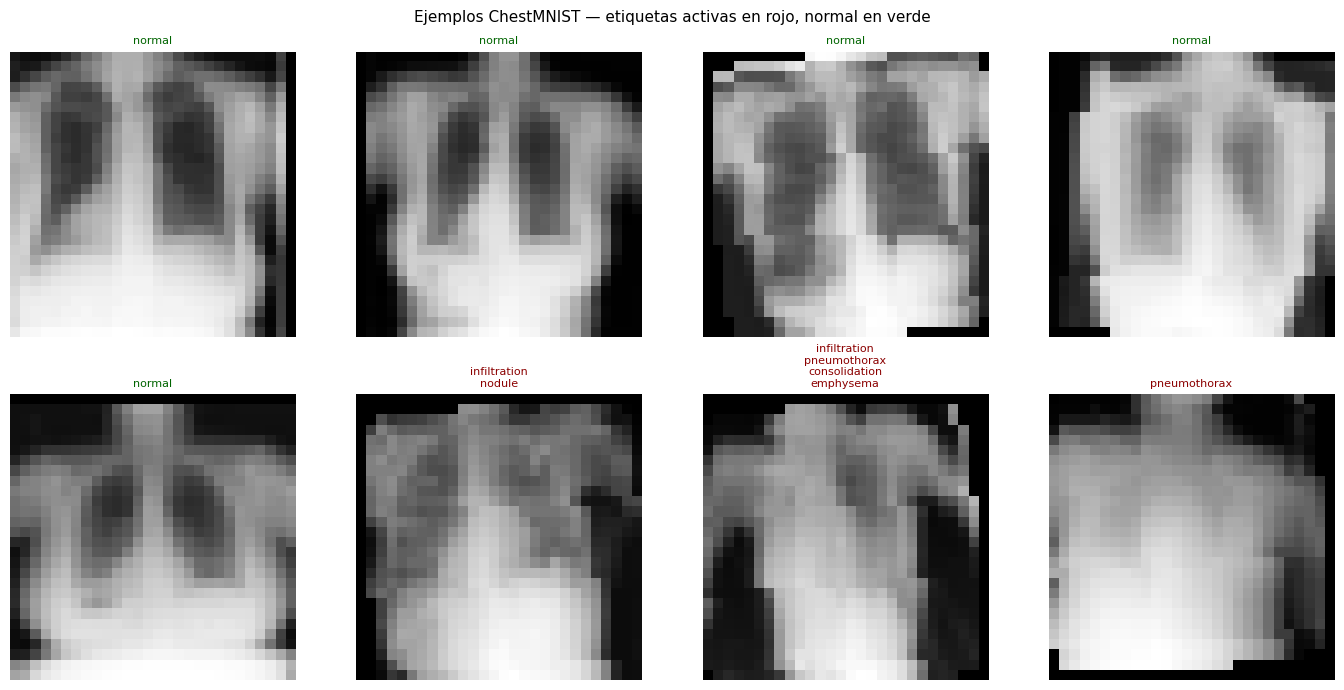

  → chest_ejemplos.png

── 4. Modelo 1: CNN desde cero ──
[CNN] Ep01 | loss=0.1991 | val_macro_auc=0.6409
[CNN] Ep02 | loss=0.1799 | val_macro_auc=0.6635
[CNN] Ep03 | loss=0.1782 | val_macro_auc=0.6815
[CNN] Ep04 | loss=0.1776 | val_macro_auc=0.6784
[CNN] Ep05 | loss=0.1765 | val_macro_auc=0.6875
[CNN] Ep06 | loss=0.1757 | val_macro_auc=0.7026
[CNN] Ep07 | loss=0.1754 | val_macro_auc=0.7061
[CNN] Ep08 | loss=0.1743 | val_macro_auc=0.7044
[CNN] Ep09 | loss=0.1740 | val_macro_auc=0.7065
[CNN] Ep10 | loss=0.1735 | val_macro_auc=0.7113

── 5. Modelo 2: Transfer Learning (ResNet18) ──

[ResNet Stage 1] Entrenando solo fc...
[TL-S1] Ep01 | loss=0.1900 | val_macro_auc=0.5941
[TL-S1] Ep02 | loss=0.1842 | val_macro_auc=0.6091
[TL-S1] Ep03 | loss=0.1832 | val_macro_auc=0.6102
[TL-S1] Ep04 | loss=0.1828 | val_macro_auc=0.6057

[ResNet Stage 2] Fine-tuning layer4 + fc...
[TL-S2] Ep01 | loss=0.1751 | val_macro_auc=0.6882
[TL-S2] Ep02 | loss=0.1700 | val_macro_auc=0.7152
[TL-S2] Ep03 | loss=0.1671 |

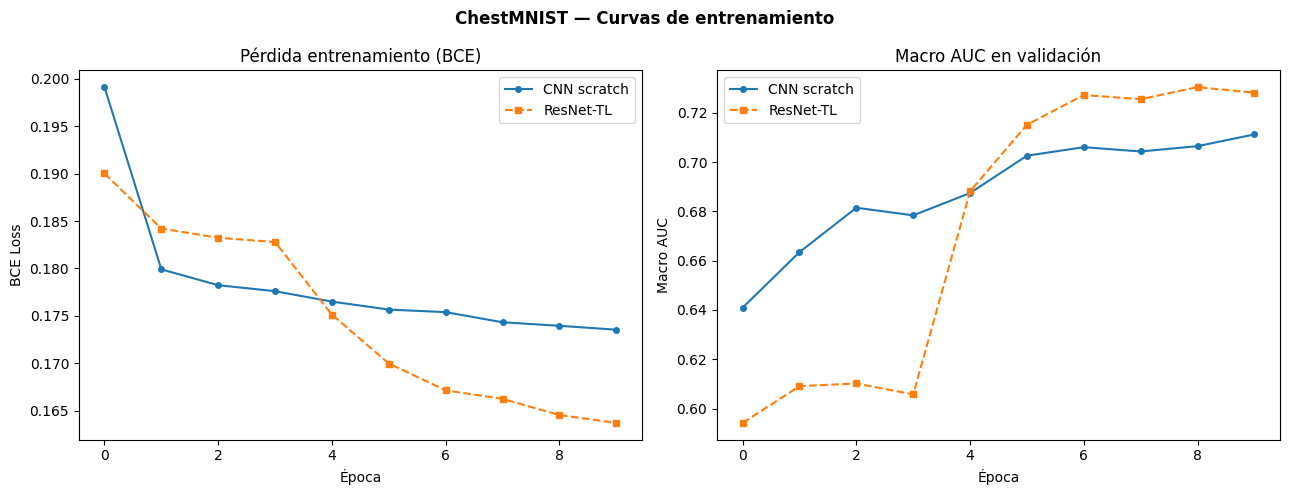

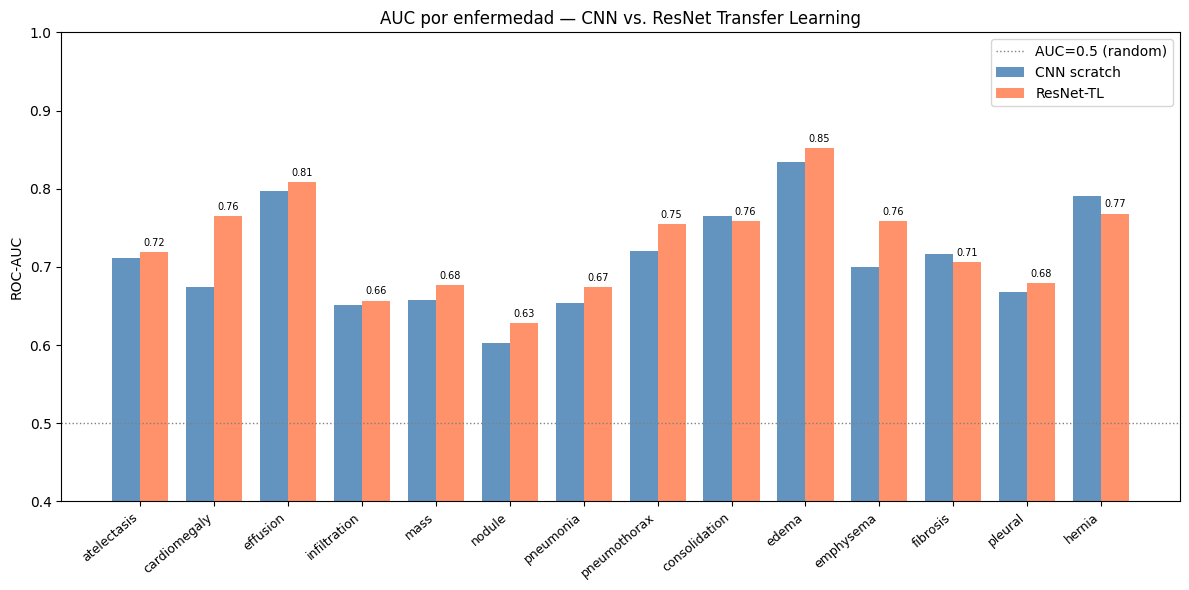


  Calculando co-ocurrencia de enfermedades...


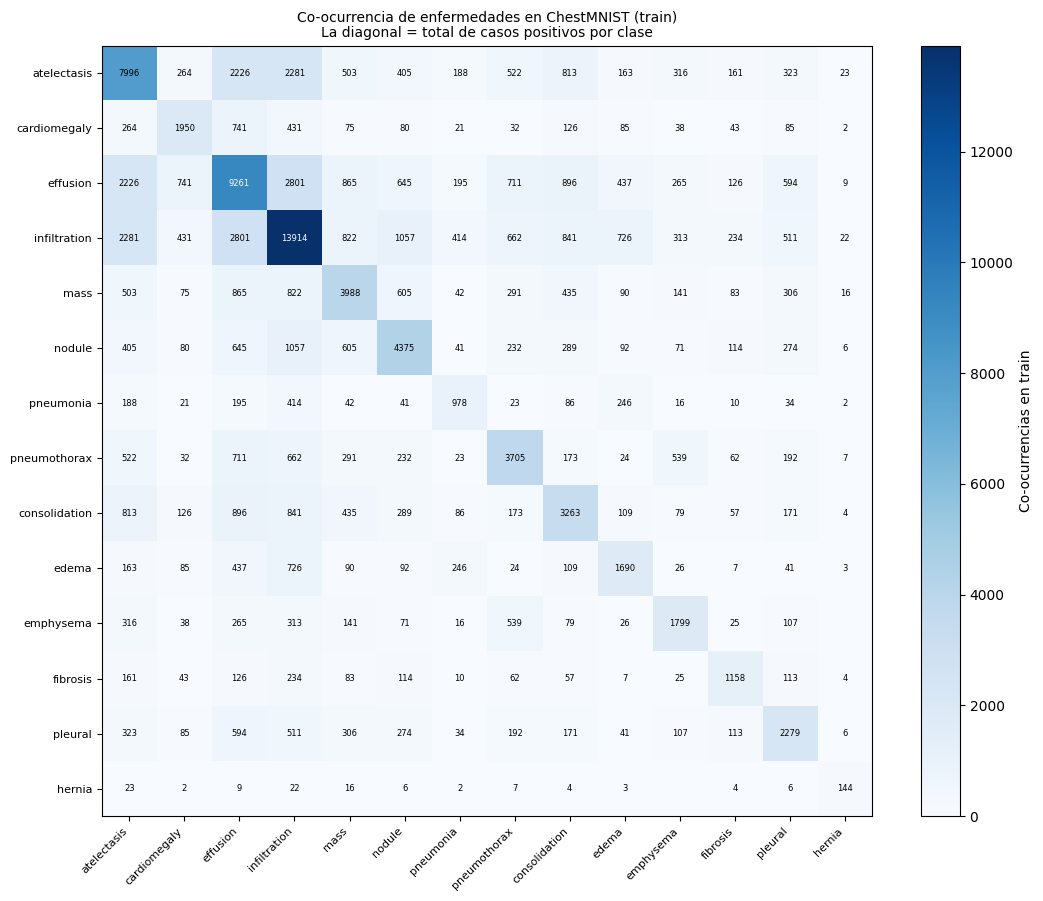


  Analizando umbrales óptimos...


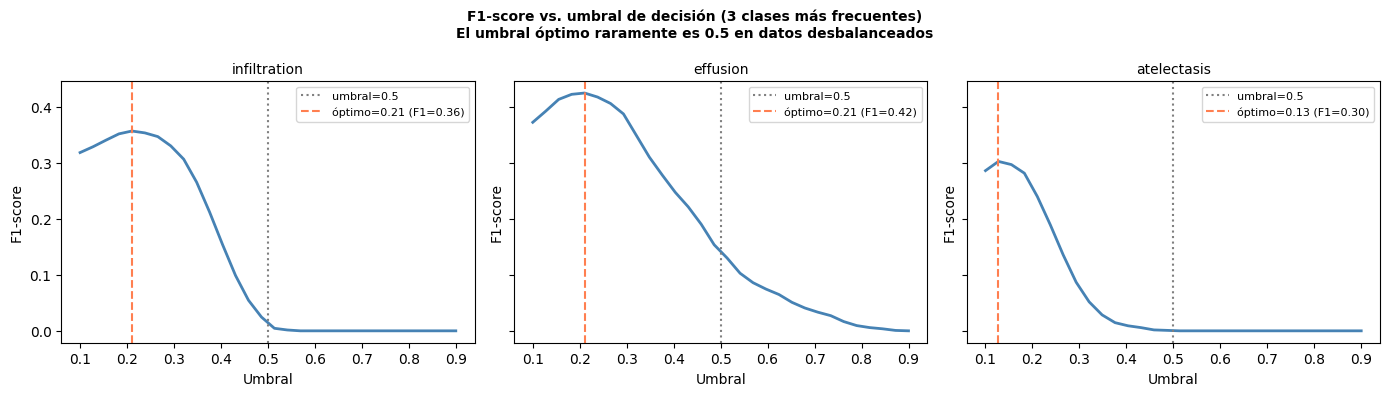

  → chest_training_curves.png
  → chest_auc_por_clase.png
  → chest_coocurrencia.png
  → chest_umbrales.png

Modelos guardados en models/

RESUMEN FINAL — ChestMNIST
  CNN desde cero  | Macro AUC: 0.7101 | F1: 0.0000
  ResNet-TL       | Macro AUC: 0.7288  | F1: 0.0113

Lecciones clave de ChestMNIST:

1. BCEWithLogitsLoss es la loss correcta para multi-etiqueta.
   CrossEntropyLoss asumiría que solo puede haber 1 clase activa.

2. El AUC varía mucho entre enfermedades. Las clases raras
   (pocas muestras positivas) tienden a tener AUC más bajo.

3. El umbral 0.5 no es siempre óptimo. Con datos desbalanceados,
   bajar el umbral (ej: 0.3) puede mejorar el recall en clases raras.

4. La co-ocurrencia de enfermedades es importante: Atelectasis
   y Effusion, por ejemplo, tienden a aparecer juntas.

5. Transfer learning (ResNet) supera claramente a la CNN desde
   cero, especialmente para clases con pocas muestras.



In [31]:
"""
===============================================================
  PIPELINE CNN — ChestMNIST
  Clasificación multi-etiqueta: 14 enfermedades de tórax
  Dataset: NIH Chest X-Ray (versión MedMNIST)
===============================================================

DIFERENCIAS CLAVE vs. PneumoniaMNIST (binario):
  • Multi-etiqueta: una imagen puede tener 0, 1 o más enfermedades
    simultáneamente. Ej: "Atelectasis + Effusion" al mismo tiempo.
  • Loss: BCEWithLogitsLoss en lugar de CrossEntropyLoss
  • Activación de salida: Sigmoid por clase (no Softmax)
  • Umbral de decisión: 0.5 por clase de forma independiente
  • Métricas: AUC por clase + macro AUC, F1 por clase
  • Etiquetas: shape (N, 14) en lugar de (N, 1)

Ejecutar en Google Colab con GPU (Runtime > Change runtime type > T4 GPU)
"""

# ── Instalación ────────────────────────────────────────────────
import sys, subprocess
for p in ["torch", "torchvision", "medmnist", "numpy",
          "matplotlib", "scikit-learn", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

# ── Imports ────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, average_precision_score,
                             classification_report)
from tqdm import tqdm
import medmnist
from medmnist import INFO

# ── Configuración ──────────────────────────────────────────────
DATA_FLAG   = "chestmnist"
info        = INFO[DATA_FLAG]
DataClass   = getattr(medmnist, info["python_class"])
NUM_CLASSES = len(info["label"])          # 14 enfermedades
BATCH_SIZE  = 128
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Las 14 etiquetas del dataset
CLASS_NAMES = [info["label"][str(i)] for i in range(NUM_CLASSES)]

print(f"Device     : {DEVICE}")
print(f"Num clases : {NUM_CLASSES}")
print(f"Clases     : {CLASS_NAMES}")
print(f"Tarea      : {info['task']}")
print(f"Muestras   : {info['n_samples']}")


# ══════════════════════════════════════════════════════════════
# 1. DATASET Y DATALOADERS
# ══════════════════════════════════════════════════════════════
print("\n── 1. Cargando ChestMNIST ──")

# Transforms: el dataset es escala de grises (1 canal)
# Para transfer learning lo convertiremos a 3 canales más adelante
transform_basic = T.Compose([T.ToTensor()])

transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomHorizontalFlip(p=0.5),       # válido en RX de tórax
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_ds = DataClass(split="train", transform=transform_aug,  download=True)
val_ds   = DataClass(split="val",   transform=transform_basic, download=True)
test_ds  = DataClass(split="test",  transform=transform_basic, download=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Verificar forma de etiquetas — IMPORTANTE: shape (N, 14) no (N, 1)
x_sample, y_sample = next(iter(train_loader))
print(f"\nForma imagen  : {x_sample.shape}")   # [128, 1, 28, 28]
print(f"Forma etiqueta: {y_sample.shape}")      # [128, 14]  ← multi-etiqueta
print(f"Tipo etiqueta : {y_sample.dtype}")

# Distribución de clases (muestras positivas por clase)
print("\nDistribución de clases en train:")
all_labels = np.array([train_ds[i][1] for i in range(len(train_ds))])
for i, name in enumerate(CLASS_NAMES):
    n_pos = int(all_labels[:, i].sum())
    pct   = 100 * n_pos / len(train_ds)
    print(f"  {name:25s}: {n_pos:5d} ({pct:.1f}%)")


# ══════════════════════════════════════════════════════════════
# 2. VISUALIZACIÓN DE EJEMPLOS
# ══════════════════════════════════════════════════════════════
def show_multilabel_batch(dataset, n=8):
    """Muestra imágenes con todas sus etiquetas activas."""
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        x, y = dataset[i]
        img    = x.squeeze(0).numpy()
        labels = [CLASS_NAMES[j] for j in range(NUM_CLASSES) if y[j] == 1]
        label_str = "\n".join(labels) if labels else "normal"
        ax.imshow(img, cmap="gray")
        ax.set_title(label_str, fontsize=8, color="darkred" if labels else "darkgreen")
        ax.axis("off")
    plt.suptitle("Ejemplos ChestMNIST — etiquetas activas en rojo, normal en verde",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig("chest_ejemplos.png", dpi=130)
    plt.show()
    print("  → chest_ejemplos.png")

show_multilabel_batch(train_ds)


# ══════════════════════════════════════════════════════════════
# 3. FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN MULTI-ETIQUETA
# ══════════════════════════════════════════════════════════════

# ── Loss: BCEWithLogitsLoss ─────────────────────────────────
# A diferencia de CrossEntropyLoss (que elige 1 clase),
# BCE trata cada una de las 14 clases como una clasificación
# binaria independiente. El modelo predice 14 scores simultáneos.
criterion = nn.BCEWithLogitsLoss()

@torch.no_grad()
def evaluate_multilabel(model, loader):
    """
    Evaluación multi-etiqueta.
    Retorna:
      - auc_per_class : AUC para cada una de las 14 enfermedades
      - macro_auc     : promedio de los 14 AUC
      - y_true        : (N, 14) etiquetas reales
      - y_prob        : (N, 14) probabilidades predichas
      - y_pred        : (N, 14) predicciones binarias (umbral=0.5)
    """
    model.eval()
    all_probs, all_labels = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        logits = model(x)                        # (B, 14)
        probs  = torch.sigmoid(logits)           # Sigmoid independiente por clase
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.numpy().astype(float))

    y_prob = np.vstack(all_probs)                # (N, 14)
    y_true = np.vstack(all_labels)               # (N, 14)
    y_pred = (y_prob >= 0.5).astype(int)         # umbral 0.5 por clase

    # AUC por clase (solo clases con al menos 1 positivo)
    auc_per_class = []
    for i in range(NUM_CLASSES):
        if y_true[:, i].sum() > 0:
            auc = roc_auc_score(y_true[:, i], y_prob[:, i])
        else:
            auc = float("nan")
        auc_per_class.append(auc)

    valid_aucs = [a for a in auc_per_class if not np.isnan(a)]
    macro_auc  = float(np.mean(valid_aucs))

    return auc_per_class, macro_auc, y_true, y_pred, y_prob


def train_one_epoch(model, loader, optimizer):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE).float()           # float para BCEWithLogitsLoss

        optimizer.zero_grad()
        logits = model(x)                  # (B, 14), sin activación
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


def train_loop(model, train_loader, val_loader, optimizer,
               epochs=8, scheduler=None, tag=""):
    history = {"train_loss": [], "val_macro_auc": []}
    for ep in range(1, epochs + 1):
        loss = train_one_epoch(model, train_loader, optimizer)
        _, macro_auc, *_ = evaluate_multilabel(model, val_loader)
        history["train_loss"].append(loss)
        history["val_macro_auc"].append(macro_auc)
        if scheduler:
            scheduler.step()
        print(f"{tag} Ep{ep:02d} | loss={loss:.4f} | val_macro_auc={macro_auc:.4f}")
    return history


# ══════════════════════════════════════════════════════════════
# 4. MODELO 1 — CNN DESDE CERO (adaptada a multi-etiqueta)
# ══════════════════════════════════════════════════════════════
print("\n── 4. Modelo 1: CNN desde cero ──")

class ChestCNN(nn.Module):
    """
    CNN para clasificación multi-etiqueta.
    Diferencia clave vs. clasificación simple:
      - La capa final tiene NUM_CLASSES=14 neuronas (una por enfermedad)
      - NO se aplica Softmax (que forzaría suma=1)
      - El loss (BCEWithLogitsLoss) aplica Sigmoid internamente
    """
    def __init__(self, num_classes=14):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(), nn.Dropout2d(0.2),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)     # 14 salidas, sin activación
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model_cnn = ChestCNN(NUM_CLASSES).to(DEVICE)
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
scheduler_cnn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cnn, T_max=10)

history_cnn = train_loop(model_cnn, train_loader, val_loader,
                          optimizer_cnn, epochs=10,
                          scheduler=scheduler_cnn, tag="[CNN]")


# ══════════════════════════════════════════════════════════════
# 5. MODELO 2 — TRANSFER LEARNING (ResNet18)
# ══════════════════════════════════════════════════════════════
print("\n── 5. Modelo 2: Transfer Learning (ResNet18) ──")

# Necesitamos 3 canales para ResNet, pero ChestMNIST es 1 canal.
# Solución: repetir el canal gris 3 veces en el transform.
transform_tl_train = T.Compose([
    T.Resize((64, 64)),                    # upscale desde 28×28
    T.RandomRotation(10),
    T.RandomHorizontalFlip(0.5),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))  # 1 canal → 3 canales
])
transform_tl_eval = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_ds_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_ds_tl   = DataClass(split="val",   transform=transform_tl_eval,  download=True)
test_ds_tl  = DataClass(split="test",  transform=transform_tl_eval,  download=True)

train_loader_tl = DataLoader(train_ds_tl, batch_size=64, shuffle=True,
                              num_workers=2, pin_memory=True)
val_loader_tl   = DataLoader(val_ds_tl,   batch_size=64, shuffle=False,
                              num_workers=2, pin_memory=True)
test_loader_tl  = DataLoader(test_ds_tl,  batch_size=64, shuffle=False,
                              num_workers=2, pin_memory=True)

# Construir ResNet18 adaptada
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)  # 14 salidas
resnet    = resnet.to(DEVICE)

# Stage 1: solo entrenar la nueva capa fc
for p in resnet.parameters():    p.requires_grad = False
for p in resnet.fc.parameters(): p.requires_grad = True

print("\n[ResNet Stage 1] Entrenando solo fc...")
opt_stage1 = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)
history_tl_s1 = train_loop(resnet, train_loader_tl, val_loader_tl,
                             opt_stage1, epochs=4, tag="[TL-S1]")

# Stage 2: descongelar layer4 + fc para fine-tuning
for name, p in resnet.named_parameters():
    if name.startswith(("layer4", "fc")):
        p.requires_grad = True

print("\n[ResNet Stage 2] Fine-tuning layer4 + fc...")
trainable = [p for p in resnet.parameters() if p.requires_grad]
opt_stage2  = torch.optim.Adam(trainable, lr=1e-4)
sched_stage2 = torch.optim.lr_scheduler.StepLR(opt_stage2, step_size=2, gamma=0.5)
history_tl_s2 = train_loop(resnet, train_loader_tl, val_loader_tl,
                             opt_stage2, epochs=6,
                             scheduler=sched_stage2, tag="[TL-S2]")


# ══════════════════════════════════════════════════════════════
# 6. EVALUACIÓN FINAL EN TEST
# ══════════════════════════════════════════════════════════════
print("\n── 6. Evaluación final en test ──")

auc_per_class_cnn, macro_auc_cnn, y_true_cnn, y_pred_cnn, y_prob_cnn = \
    evaluate_multilabel(model_cnn, test_loader)

auc_per_class_tl, macro_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = \
    evaluate_multilabel(resnet, test_loader_tl)

print(f"\n{'Enfermedad':25s} {'AUC CNN':>9} {'AUC ResNet':>10}")
print("─" * 47)
for i, name in enumerate(CLASS_NAMES):
    a_cnn = auc_per_class_cnn[i]
    a_tl  = auc_per_class_tl[i]
    print(f"  {name:23s} {a_cnn:8.4f}   {a_tl:8.4f}")
print("─" * 47)
print(f"  {'MACRO AUC':23s} {macro_auc_cnn:8.4f}   {macro_auc_tl:8.4f}")

# F1 score macro (con umbral 0.5)
f1_cnn = f1_score(y_true_cnn, y_pred_cnn, average="macro", zero_division=0)
f1_tl  = f1_score(y_true_tl,  y_pred_tl,  average="macro", zero_division=0)
print(f"\n  Macro F1 (umbral=0.5):")
print(f"    CNN desde cero : {f1_cnn:.4f}")
print(f"    ResNet-TL      : {f1_tl:.4f}")


# ══════════════════════════════════════════════════════════════
# 7. VISUALIZACIONES
# ══════════════════════════════════════════════════════════════
print("\n── 7. Generando gráficas ──")

# ── 7a. Curvas de entrenamiento ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_cnn["train_loss"],     label="CNN scratch", marker="o", ms=4)
all_tl_loss = (history_tl_s1["train_loss"] + history_tl_s2["train_loss"])
axes[0].plot(all_tl_loss, label="ResNet-TL", marker="s", ms=4, linestyle="--")
axes[0].set_title("Pérdida entrenamiento (BCE)")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("BCE Loss"); axes[0].legend()

all_tl_auc = (history_tl_s1["val_macro_auc"] + history_tl_s2["val_macro_auc"])
axes[1].plot(history_cnn["val_macro_auc"],  label="CNN scratch", marker="o", ms=4)
axes[1].plot(all_tl_auc, label="ResNet-TL", marker="s", ms=4, linestyle="--")
axes[1].set_title("Macro AUC en validación")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Macro AUC"); axes[1].legend()

fig.suptitle("ChestMNIST — Curvas de entrenamiento", fontweight="bold")
plt.tight_layout(); plt.savefig("chest_training_curves.png", dpi=130); plt.show()

# ── 7b. AUC por enfermedad ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(NUM_CLASSES)
w = 0.38
bars1 = ax.bar(x - w/2, auc_per_class_cnn, w, label="CNN scratch",  color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + w/2, auc_per_class_tl,  w, label="ResNet-TL",    color="coral",      alpha=0.85)
ax.axhline(0.5, color="gray", linestyle=":", lw=1, label="AUC=0.5 (random)")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0.4, 1.0)
ax.set_title("AUC por enfermedad — CNN vs. ResNet Transfer Learning")
ax.legend()
# Anotar valores
for bar in bars2:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f"{h:.2f}", ha="center", fontsize=7)
plt.tight_layout(); plt.savefig("chest_auc_por_clase.png", dpi=130); plt.show()

# ── 7c. Heatmap de co-ocurrencia de enfermedades ──────────────
#  Útil para entender el desafío multi-etiqueta
print("\n  Calculando co-ocurrencia de enfermedades...")
all_train_labels = np.array([train_ds[i][1] for i in range(len(train_ds))])
cooccurrence = all_train_labels.T @ all_train_labels   # (14, 14)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cooccurrence, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cooccurrence[i, j] > 0:
            ax.text(j, i, int(cooccurrence[i, j]),
                    ha="center", va="center", fontsize=6,
                    color="white" if cooccurrence[i, j] > cooccurrence.max()*0.6 else "black")
plt.colorbar(im, ax=ax, label="Co-ocurrencias en train")
ax.set_title("Co-ocurrencia de enfermedades en ChestMNIST (train)\n"
             "La diagonal = total de casos positivos por clase",
             fontsize=10)
plt.tight_layout(); plt.savefig("chest_coocurrencia.png", dpi=130); plt.show()

# ── 7d. Análisis de umbral óptimo ─────────────────────────────
#  En medicina, el umbral 0.5 no siempre es el mejor.
#  Aquí mostramos F1 vs umbral para las 3 clases con más muestras.
print("\n  Analizando umbrales óptimos...")
top3_classes = np.argsort(all_train_labels.sum(axis=0))[-3:][::-1]
thresholds   = np.linspace(0.1, 0.9, 30)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, cls_idx in zip(axes, top3_classes):
    f1s = []
    for t in thresholds:
        preds = (y_prob_tl[:, cls_idx] >= t).astype(int)
        f1    = f1_score(y_true_tl[:, cls_idx], preds, zero_division=0)
        f1s.append(f1)
    best_t  = thresholds[np.argmax(f1s)]
    best_f1 = max(f1s)
    ax.plot(thresholds, f1s, lw=2, color="steelblue")
    ax.axvline(0.5,    color="gray",   linestyle=":", label="umbral=0.5")
    ax.axvline(best_t, color="coral",  linestyle="--",
               label=f"óptimo={best_t:.2f} (F1={best_f1:.2f})")
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=10)
    ax.set_xlabel("Umbral"); ax.set_ylabel("F1-score")
    ax.legend(fontsize=8)

fig.suptitle("F1-score vs. umbral de decisión (3 clases más frecuentes)\n"
             "El umbral óptimo raramente es 0.5 en datos desbalanceados",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.savefig("chest_umbrales.png", dpi=130); plt.show()

print("  → chest_training_curves.png")
print("  → chest_auc_por_clase.png")
print("  → chest_coocurrencia.png")
print("  → chest_umbrales.png")


# ══════════════════════════════════════════════════════════════
# 8. GUARDAR MODELOS
# ══════════════════════════════════════════════════════════════
import os
os.makedirs("models", exist_ok=True)
torch.save(model_cnn.state_dict(), "models/chest_cnn_scratch.pth")
torch.save(resnet.state_dict(),    "models/chest_resnet_tl.pth")
print("\nModelos guardados en models/")


# ══════════════════════════════════════════════════════════════
# 9. RESUMEN FINAL
# ══════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("RESUMEN FINAL — ChestMNIST")
print("="*55)
print(f"  CNN desde cero  | Macro AUC: {macro_auc_cnn:.4f} | F1: {f1_cnn:.4f}")
print(f"  ResNet-TL       | Macro AUC: {macro_auc_tl:.4f}  | F1: {f1_tl:.4f}")
print("""
Lecciones clave de ChestMNIST:

1. BCEWithLogitsLoss es la loss correcta para multi-etiqueta.
   CrossEntropyLoss asumiría que solo puede haber 1 clase activa.

2. El AUC varía mucho entre enfermedades. Las clases raras
   (pocas muestras positivas) tienden a tener AUC más bajo.

3. El umbral 0.5 no es siempre óptimo. Con datos desbalanceados,
   bajar el umbral (ej: 0.3) puede mejorar el recall en clases raras.

4. La co-ocurrencia de enfermedades es importante: Atelectasis
   y Effusion, por ejemplo, tienden a aparecer juntas.

5. Transfer learning (ResNet) supera claramente a la CNN desde
   cero, especialmente para clases con pocas muestras.
""")